# Text Classification by XGBoost & Others

https://pub.towardsai.net/text-classification-by-xgboost-others-a-case-study-using-bbc-news-articles-5d88e94a9f8

This example is a 5-class classification

## 1.0 - Getting the data

In [3]:
import pandas as pd

bbc_text_df = pd.read_csv('bbc-text.csv')
bbc_text_df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [26]:
bbc_text_df.shape

(2225, 2)

## 2.0 - Data Exploration & Visualization

Explore how many categories are there.

Each bar shows the number of documents per category (e.g., sport, business, tech, politics, entertainment).

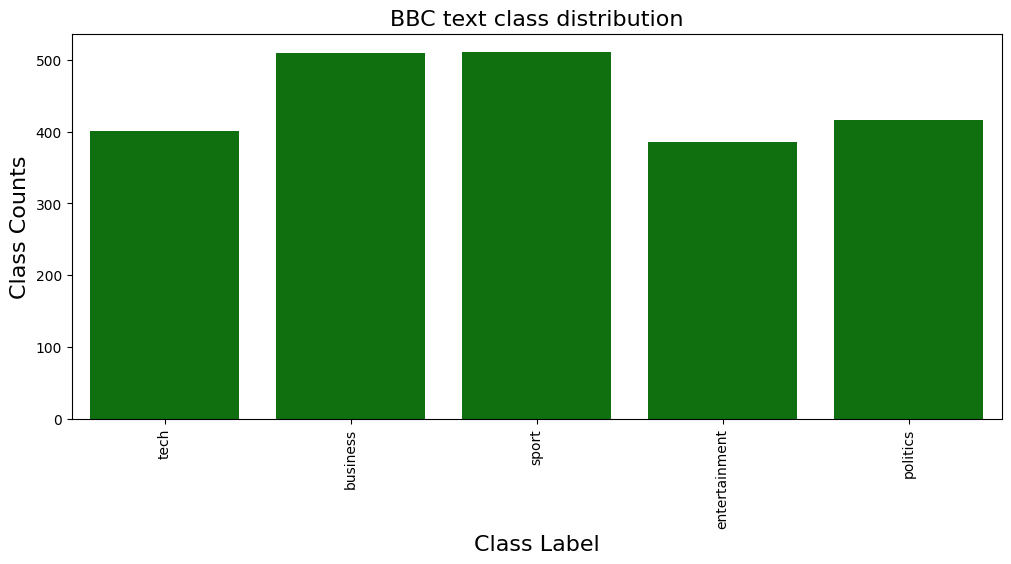

In [4]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(x=bbc_text_df.category, color='green')
plt.title('BBC text class distribution', fontsize=16)
plt.ylabel('Class Counts', fontsize=16)
plt.xlabel('Class Label', fontsize=16)
plt.xticks(rotation='vertical');

**EDA:** From the plot, it is clear that there is not that much skewness in the class distribution.

---

## 🧹 Perform text cleaning

## Steps

1. **Conversion to lowercase**
   Ensures uniformity, so `Apple` and `apple` are treated the same.

2. **Removal of punctuations**
   Deletes characters like `. , ! ? : ;` etc.

3. **Removal of integers and numbers**
   Eliminates digits such as `123`, `2025`.

4. **Removal of extra spaces**
   Converts multiple spaces into a single space.

5. **Removal of tags (HTML/XML)**
   Removes markup like `<html>`, `<p>`, `<br>`.

6. **Removal of stop words**
   Discards frequent words like *and, the, to, is* that carry little meaning.

7. **Stemming**
   Reduces words to their root form.
   Example: *running → run, studies → studi*

---

## Example Code (Python)

```python
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already present
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 4. Remove numbers
    text = re.sub(r'\d+', ' ', text)
    
    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 6. Remove stopwords
    words = [word for word in text.split() if word not in stop_words]
    
    # 7. Apply stemming
    words = [stemmer.stem(word) for word in words]
    
    return ' '.join(words)
```

---

## ✅ Example Transformation

**Original Text:**

```
WorldCom boss left books alone! <p> Former WorldCom CEO faces 25 years in prison.
```

**After Cleaning:**

```
worldcom boss left book alon former worldcom ceo face year prison
```

---


In this example, we will use use Python ‘gensim’ library for all text cleaning

In [5]:
%pip install gensim

In [6]:
from gensim import utils
import gensim.parsing.preprocessing as gsp

filters = [
           gsp.strip_tags,
           gsp.strip_punctuation,
           gsp.strip_multiple_whitespaces,
           gsp.strip_numeric,
           gsp.remove_stopwords,
           gsp.strip_short,
           gsp.stem_text
          ]

def clean_text(s):
    s = s.lower()
    s = utils.to_unicode(s)
    for f in filters:
        s = f(s)
    return s

### Before cleaning

In [7]:
bbc_text_df.iloc[2,1]

'tigers wary of farrell  gamble  leicester say they will not be rushed into making a bid for andy farrell should the great britain rugby league captain decide to switch codes.   we and anybody else involved in the process are still some way away from going to the next stage   tigers boss john wells told bbc radio leicester.  at the moment  there are still a lot of unknowns about andy farrell  not least his medical situation.  whoever does take him on is going to take a big  big gamble.  farrell  who has had persistent knee problems  had an operation on his knee five weeks ago and is expected to be out for another three months. leicester and saracens are believed to head the list of rugby union clubs interested in signing farrell if he decides to move to the 15-man game.  if he does move across to union  wells believes he would better off playing in the backs  at least initially.  i m sure he could make the step between league and union by being involved in the centre   said wells.  i t

After cleaning

In [8]:
clean_text(bbc_text_df.iloc[2,1])

'tiger wari farrel gambl leicest rush make bid andi farrel great britain rugbi leagu captain decid switch code anybodi involv process wai awai go stage tiger boss john well told bbc radio leicest moment lot unknown andi farrel medic situat go big big gambl farrel persist knee problem oper knee week ago expect month leicest saracen believ head list rugbi union club interest sign farrel decid man game union well believ better plai back initi sure step leagu union involv centr said well think england prefer progress posit row us rugbi leagu skill forward juri cross divid club balanc struck cost gambl option bring readi replac'

## Visualize as word cloud

In [9]:
%matplotlib inline

from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud_instance = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords=None,
                min_font_size = 10).generate(text)

    plt.figure(figsize = (8, 8), facecolor = None)
    plt.imshow(wordcloud_instance)
    plt.axis("off")
    plt.tight_layout(pad = 0)
    plt.show()

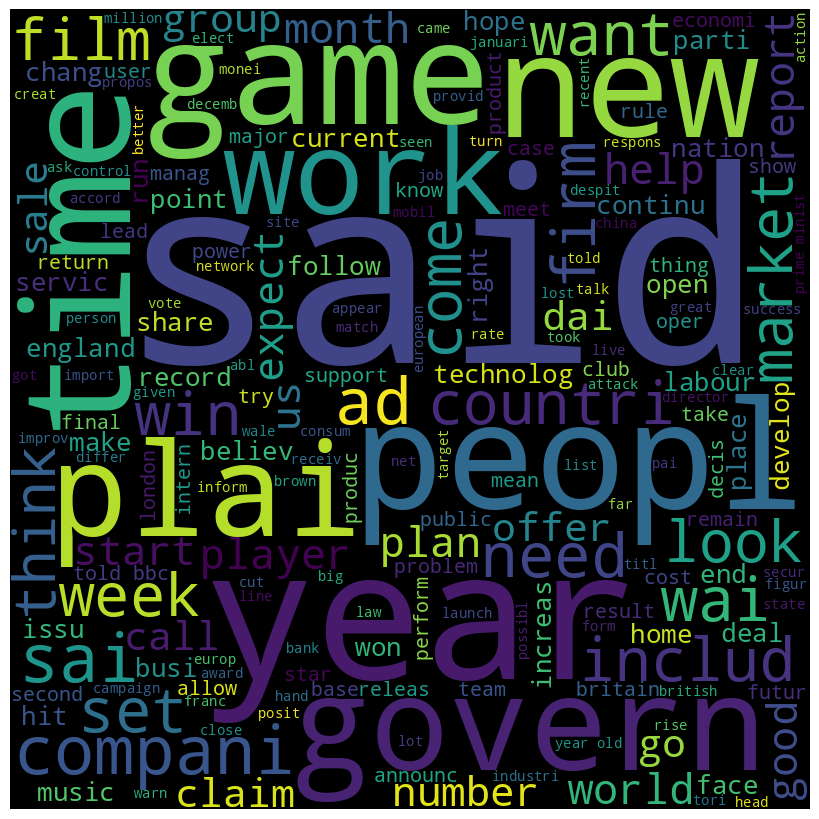

In [10]:
texts = ''
for index, item in bbc_text_df.iterrows():
    texts = texts + ' ' + clean_text(item['text'])

plot_word_cloud(texts)

Bigger words indicate **more frequent**. So, **year**, **time**, **peopl** etc are the most frequent words.

### Word Cloud’ of ‘text’ for a particular ‘category’.

In [11]:
def plot_word_cloud_for_category(bbc_text_df, category):
    text_df = bbc_text_df.loc[bbc_text_df['category'] == str(category)]
    texts = ''
    for index, item in text_df.iterrows():
        texts = texts + ' ' + clean_text(item['text'])

    plot_word_cloud(texts)

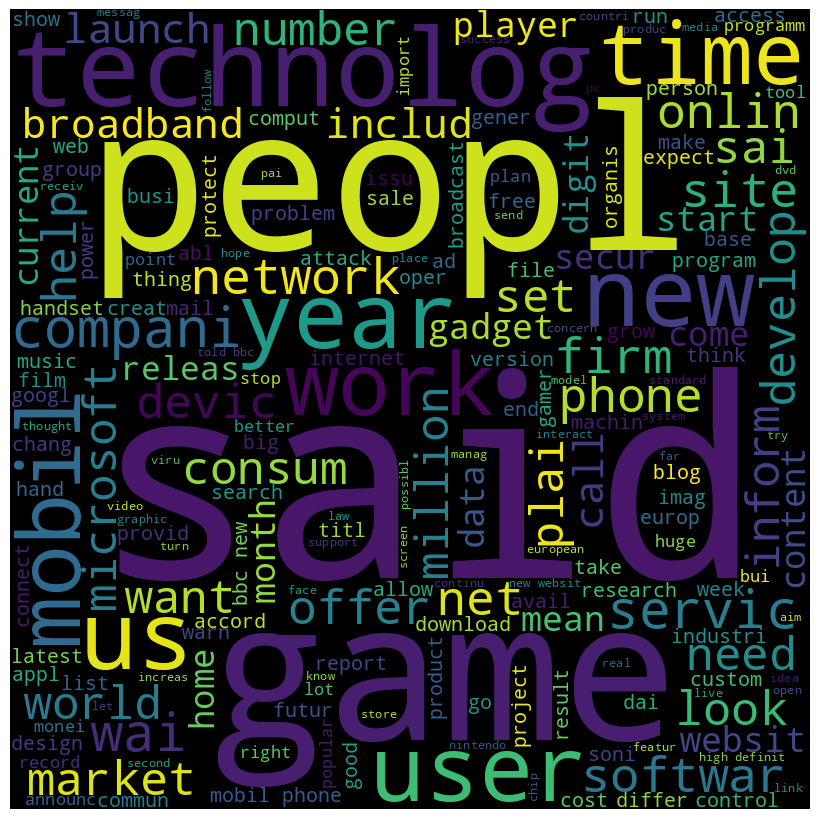

In [12]:
# the ‘Word Cloud’ for ‘category’ ‘tech’
plot_word_cloud_for_category(bbc_text_df,'tech')

So, for category ‘tech’ most frequent words are ‘peopl’, ‘techlog’ ‘game’ etc

### Word Cloud’ of ‘text’ for a particular ‘category’ `sport`.

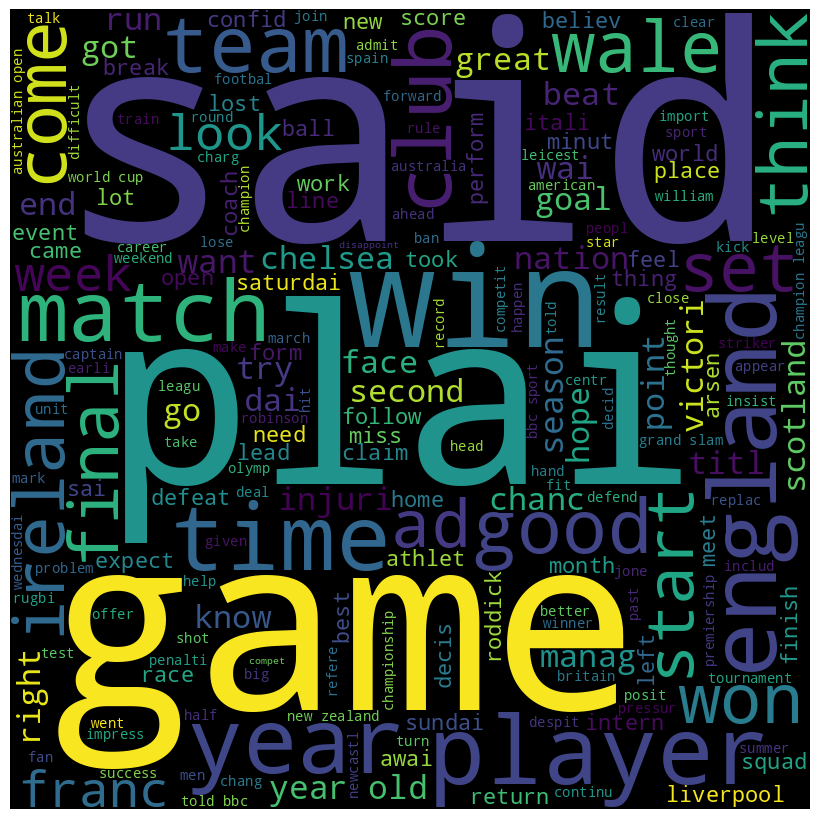

In [13]:
plot_word_cloud_for_category(bbc_text_df,'sport')

Most frequent words are ‘plai’, ‘game’, ‘player’, ‘win’, ‘match’, ‘England’ etc

### **Word Cloud of `text` for `category politics`.**

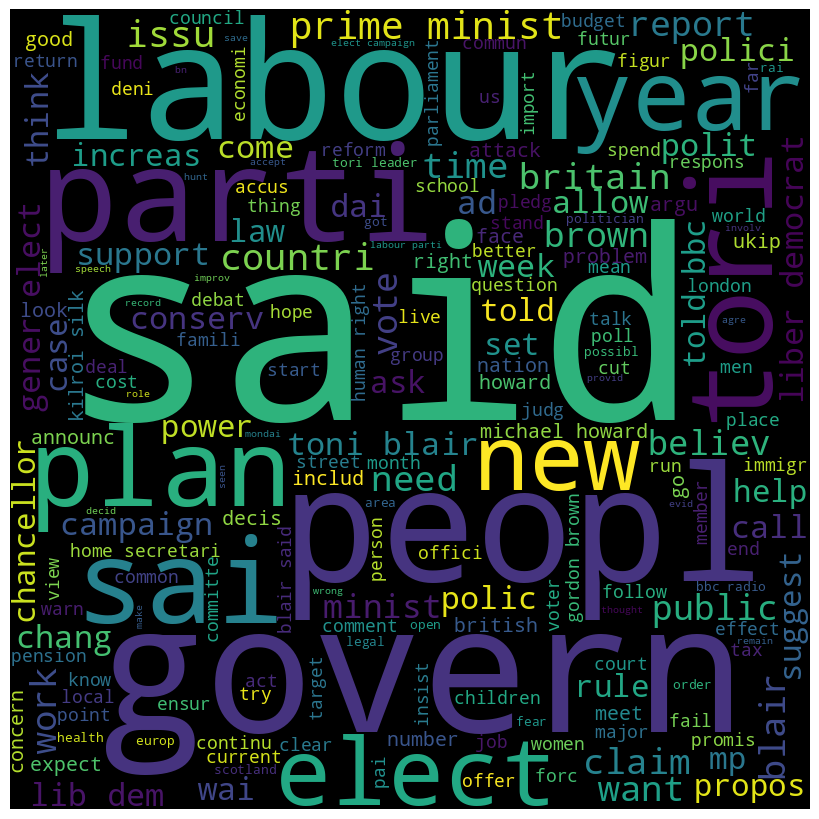

In [14]:
plot_word_cloud_for_category(bbc_text_df,'politics')

`govern`, `peopl`, `blair`, `countri`, `minist` are the most frequent words.

**Conclusion**: Each category has some words which are distinguishing those from other categories. Or it may be like this: each `text` is inferring some context in it which is determining its category

## Vector Space Modelling & Building the Pipeline

We will try with the two most popular vector space models: `Doc2Vec` & `Tf-Idf`.

Split the data into features and categories

In [15]:
df_x = bbc_text_df['text']
df_y = bbc_text_df['category']

### Use Doc2Vec from Gensim Library

In [ ]:
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
from sklearn.base import BaseEstimator
from sklearn import utils as skl_utils
from tqdm import tqdm

import multiprocessing
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

class Doc2VecTransformer(BaseEstimator):

    def __init__(self, vector_size=100, learning_rate=0.02, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self._model = None
        self.vector_size = vector_size
        self.workers = multiprocessing.cpu_count() - 1

    def fit(self, df_x, df_y=None):
        tagged_x = [TaggedDocument(clean_text(row).split(), [index]) for index, row in enumerate(df_x)]
        model = Doc2Vec(documents=tagged_x, vector_size=self.vector_size, workers=self.workers)

        for epoch in range(self.epochs):
            model.train(skl_utils.shuffle([x for x in tqdm(tagged_x)]), total_examples=len(tagged_x), epochs=1)
            model.alpha -= self.learning_rate
            model.min_alpha = model.alpha

        self._model = model
        return self

    def transform(self, df_x):
        # Modified to return a numpy array instead of a numpy matrix
        return np.asarray([self._model.infer_vector(clean_text(row).split())
                                     for index, row in enumerate(df_x)])

We will see how does the ‘Doc2Vec’ look like by applying this transformer

In [ ]:
doc2vec_trf = Doc2VecTransformer()
doc2vec_features = doc2vec_trf.fit(df_x).transform(df_x)
doc2vec_features

So, it is a numerical representation of the text data. We can use these numerical features into any machine learning algorithm. We will try with LogisticRegression, RandomForest & XGBoost

### **Doc2Vec & LogisticRegression pipeline**

In [16]:
pl_log_reg = Pipeline(steps=[('doc2vec',Doc2VecTransformer()),
                             ('log_reg', LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, n_jobs=-1))]) # Updated solver and max_iter
scores = cross_val_score(pl_log_reg, df_x, df_y, cv=5,scoring='accuracy', error_score='raise') # Added error_score

print('Accuracy for Logistic Regression: ', scores.mean())

100%|██████████| 1780/1780 [00:00<00:00, 3450028.24it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
100%|██████████| 1780/1780 [00:00<00:00, 3421567.88it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
100%|██████████| 1780/1780 [00:00<00:00, 3423136.69it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this 

Accuracy for Logistic Regression:  0.48764044943820223


Accuracy for Logistic Regression:  0.48764044943820223 is low

### **Doc2Vec & RandomForest pipeline**

In [17]:
from sklearn.ensemble import RandomForestClassifier

pl_random_forest = Pipeline(steps=[('doc2vec',Doc2VecTransformer()),
                                   ('random_forest', RandomForestClassifier())])
scores = cross_val_score(pl_random_forest, df_x, df_y, cv=5,scoring='accuracy')
print('Accuracy for RandomForest : ', scores.mean())

100%|██████████| 1780/1780 [00:00<00:00, 1205143.04it/s]


Accuracy for RandomForest :  0.43640449438202256


Accuracy for RandomForest :  0.43640449438202256 which is NOT great!

### **Doc2Vec & XGBoost pipeline**

In [21]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assuming Doc2VecTransformer and clean_text are defined in previous cells and work correctly.

# Encode the target variable df_y
label_encoder = LabelEncoder()
df_y_encoded = label_encoder.fit_transform(df_y)


# Modify the pipeline to use the standard Pipeline class
pl_xgb = Pipeline(steps=[
    ('doc2vec', Doc2VecTransformer()),
    ('xgboost', xgb.XGBClassifier(objective='multi:softmax'))
])

# Use the encoded target variable in cross_val_score
scores = cross_val_score(pl_xgb, df_x, df_y_encoded, cv=5, error_score='raise')
print('Accuracy for XGBoost Classifier : ', scores.mean())

100%|██████████| 1780/1780 [00:00<00:00, 2197780.72it/s]


Accuracy for XGBoost Classifier :  0.4453932584269663


## TF-IDF

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

class Text2TfIdfTransformer(BaseEstimator):

    def __init__(self):
        self._model = TfidfVectorizer()
        pass

    def fit(self, df_x, df_y=None):
        df_x = df_x.apply(lambda x : clean_text(x))
        self._model.fit(df_x)
        return self

    def transform(self, df_x):
        return self._model.transform(df_x)

In [23]:
tfidf_transformer = Text2TfIdfTransformer()
tfidf_vectors = tfidf_transformer.fit(df_x).transform(df_x)

In [24]:
tfidf_vectors.shape

(2225, 18754)

There are total 18754 no of tokens

In [27]:
print(tfidf_vectors)

  (0, 151)	0.02799512257292802
  (0, 440)	0.0161969544725564
  (0, 654)	0.02054130009738155
  (0, 946)	0.24805819336770085
  (0, 1377)	0.04127203969284175
  (0, 1382)	0.24805819336770085
  (0, 1635)	0.016179285549828726
  (0, 1637)	0.017248049746962486
  (0, 1646)	0.026876689466602446
  (0, 1907)	0.020124614597535187
  (0, 2033)	0.06720301719704935
  (0, 2149)	0.04800224709525704
  (0, 2150)	0.022803648347794265
  (0, 2268)	0.046738924107321056
  (0, 2353)	0.15912000468267173
  (0, 2474)	0.23868000702400763
  (0, 2812)	0.07051086505063144
  (0, 2912)	0.015271649142912389
  (0, 3380)	0.017184003556022318
  (0, 3494)	0.08709200154621774
  (0, 3507)	0.08670201778162609
  (0, 3536)	0.017184003556022318
  (0, 3846)	0.03224800196578606
  (0, 4503)	0.04354600077310887
  (0, 4556)	0.02062061813308612
  :	:
  (2224, 12069)	0.06443965774135665
  (2224, 12093)	0.05597359218279201
  (2224, 12649)	0.03763128050517815
  (2224, 12687)	0.03858516924179776
  (2224, 12877)	0.04395892441025166
  (2224, 1

### **Tf-Idf & LogisticRegression**

In [28]:
pl_log_reg_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                             ('log_reg', LogisticRegression(multi_class='multinomial', solver='saga', max_iter=100))])
scores = cross_val_score(pl_log_reg_tf_idf, df_x, df_y, cv=5,scoring='accuracy')

print('Accuracy for Tf-Idf & Logistic Regression: ', scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid t

Accuracy for Tf-Idf & Logistic Regression:  0.8966292134831461


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy for Tf-Idf & Logistic Regression:  0.8966292134831461

### Tf-Idf & RandomForest

In [29]:
pl_random_forest_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                                   ('random_forest', RandomForestClassifier())])
scores = cross_val_score(pl_random_forest_tf_idf, df_x, df_y, cv=5,scoring='accuracy')

print('Accuracy for Tf-Idf & RandomForest : ', scores.mean())

Accuracy for Tf-Idf & RandomForest :  0.9420224719101122


Accuracy for Tf-Idf & RandomForest :  0.9420224719101122

### Tf-Idf & XGBoost

In [31]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Assuming Text2TfIdfTransformer is defined and works correctly.

# Encode the target variable df_y
label_encoder = LabelEncoder()
df_y_encoded = label_encoder.fit_transform(df_y)

pl_xgb_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                         ('xgboost', xgb.XGBClassifier(objective='multi:softmax'))])

# Use the encoded target variable in cross_val_score
scores = cross_val_score(pl_xgb_tf_idf, df_x, df_y_encoded, cv=5)

print('Accuracy for Tf-Idf & XGBoost Classifier : ', scores.mean())

Accuracy for Tf-Idf & XGBoost Classifier :  0.9289887640449438


Accuracy for Tf-Idf & XGBoost Classifier :  0.9289887640449438